In [11]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional
from langchain_groq import ChatGroq
from pydantic import BaseModel
from dotenv import load_dotenv
import json

load_dotenv()

True

In [2]:
model = ChatGroq(model="openai/gpt-oss-20b")


In [3]:
class EmployeeState(BaseModel):

    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int = 0
    bonous_amount: float = 0.0
    project_status: str = ""
    summary: str = ""



 full state pathano jabe na parallel workflow te karon parallelly kaaj korle conflict kore

In [4]:
def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = (state.monthly_salary)*12
    
    return {
        'yearly_salary': yearly_salary
    }

In [5]:
def calculate_bonus(state: EmployeeState):
    bonous_amount = state.yearly_salary * 0.9

    return {
        'bonous_amount': bonous_amount
    }

In [6]:
def project_evaluation(state: EmployeeState):
    if state.completed_projects >= 5:
        status = 'E'
    else:
        status = 'A'

    return {
        'project_status': status
    }

In [7]:
def create_summary(state: EmployeeState):
    bonous_amount = state.bonous_amount
    project_status = state.project_status
    yearly_salary = state.yearly_salary

    prompt = f"""
    Generate an employee summary.

    Employee: {state.employee_name}
    Project Status: {state.project_status}
    Yearly Salary: {state.yearly_salary}
    Bonus Amount: {state.bonous_amount}
    """
    response = model.invoke(prompt).content

    return {
        'summary': response
    }

In [8]:
graph = StateGraph(EmployeeState)

graph.add_node("calculate_yearly_salary", calculate_yearly_salary)
graph.add_node("calculate_bonus", calculate_bonus)
graph.add_node("project_evaluation", project_evaluation)
graph.add_node("create_summary", create_summary)

graph.add_edge(START, "calculate_yearly_salary")
graph.add_edge(START, "calculate_bonus")
graph.add_edge(START, "project_evaluation")

graph.add_edge("calculate_yearly_salary", "create_summary")
graph.add_edge("calculate_bonus", "create_summary")
graph.add_edge("project_evaluation", "create_summary")
graph.add_edge("create_summary", END)

workflow = graph.compile()

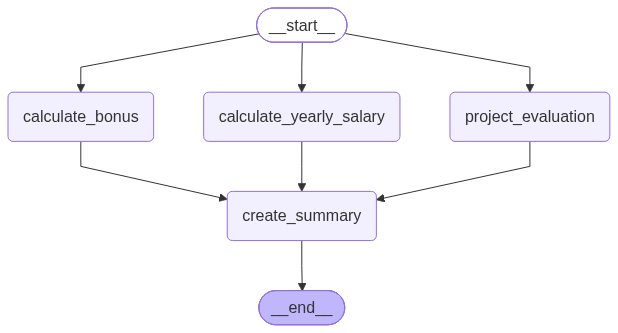

In [9]:
workflow

In [12]:
result = workflow.invoke(
    {
        "employee_name": "John",
        "monthly_salary": 50000,
        "working_days": 25,
        "completed_projects": 7
    }
)

print(json.dumps(result, indent=4))

{
    "employee_name": "John",
    "monthly_salary": 50000,
    "working_days": 25,
    "completed_projects": 7,
    "yearly_salary": 600000,
    "bonous_amount": 0.0,
    "project_status": "E",
    "summary": "**Employee Summary \u2013 John**\n\n- **Name:** John  \n- **Project Status:**\u202fE  \n  - (Typically, \u201cE\u201d denotes an *Excellent* rating or *Enrolled* status on current projects.)  \n- **Annual Compensation:**  \n  - **Base Salary:**\u202f$600,000  \n  - **Bonus:**\u202f$0.00  \n- **Key Takeaway:**  \n  John is a high\u2011earning employee with a strong project standing, but he received no bonus for the year. This could indicate a focus on base salary compensation or a lack of performance\u2011based incentives for the current period."
}
